In [25]:
import pandas as pd
import numpy as np
import scipy as sp
import os
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
lotto_df = pd.read_csv('12feb_lotto.csv', header=None)


In [3]:
lotto_df

,0,1,2,3,4,5,6,7,8,9
0,Lotto Texas,11,14,1992,13,16,22,29,32,36
1,Lotto Texas,11,18,1992,27,31,39,44,45,47
2,Lotto Texas,11,21,1992,11,21,24,28,31,46
3,Lotto Texas,11,25,1992,14,21,36,39,40,42
4,Lotto Texas,11,28,1992,9,17,21,24,28,50
...,...,...,...,...,...,...,...,...,...,...
3542,Lotto Texas,2,1,2025,51,12,4,2,54,42
3543,Lotto Texas,2,3,2025,37,54,5,20,31,6
3544,Lotto Texas,2,5,2025,43,49,27,3,54,41
3545,Lotto Texas,2,8,2025,41,25,32,54,48,10


In [4]:
lotto_df.drop(lotto_df.columns[0], axis=1)

,1,2,3,4,5,6,7,8,9
0,11,14,1992,13,16,22,29,32,36
1,11,18,1992,27,31,39,44,45,47
2,11,21,1992,11,21,24,28,31,46
3,11,25,1992,14,21,36,39,40,42
4,11,28,1992,9,17,21,24,28,50
...,...,...,...,...,...,...,...,...,...
3542,2,1,2025,51,12,4,2,54,42
3543,2,3,2025,37,54,5,20,31,6
3544,2,5,2025,43,49,27,3,54,41
3545,2,8,2025,41,25,32,54,48,10


In [5]:
lotto_df.dtypes


0    object
1     int64
2     int64
3     int64
4     int64
5     int64
6     int64
7     int64
8     int64
9     int64
dtype: object

In [5]:
print(lotto_df.head())


             0   1   2     3   4   5   6   7   8   9
0  Lotto Texas  11  14  1992  13  16  22  29  32  36
1  Lotto Texas  11  18  1992  27  31  39  44  45  47
2  Lotto Texas  11  21  1992  11  21  24  28  31  46
3  Lotto Texas  11  25  1992  14  21  36  39  40  42
4  Lotto Texas  11  28  1992   9  17  21  24  28  50


In [6]:
lotto_df = lotto_df.drop(lotto_df.columns[0], axis=1)



In [8]:
print(lotto_df.dtypes)


1    int64
2    int64
3    int64
4    int64
5    int64
6    int64
7    int64
8    int64
9    int64
dtype: object


In [7]:
# Combine the first three columns (month, day, year) into a single 'date' column
lotto_df['date'] = pd.to_datetime(
    lotto_df.iloc[:, 0].astype(str) + '/' +
    lotto_df.iloc[:, 1].astype(str) + '/' +
    lotto_df.iloc[:, 2].astype(str),
    errors='coerce'  # Ignore invalid parsing
)

# Drop the original 'month', 'day', and 'year' columns
lotto_df = lotto_df.drop(lotto_df.columns[:3], axis=1)

# Display the updated DataFrame
print(lotto_df.head())


    4   5   6   7   8   9       date
0  13  16  22  29  32  36 1992-11-14
1  27  31  39  44  45  47 1992-11-18
2  11  21  24  28  31  46 1992-11-21
3  14  21  36  39  40  42 1992-11-25
4   9  17  21  24  28  50 1992-11-28


In [8]:
columns = ['date'] + [col for col in lotto_df.columns if col != 'date']
lotto_df = lotto_df[columns]

In [9]:
lotto_df

,date,4,5,6,7,8,9
0,1992-11-14,13,16,22,29,32,36
1,1992-11-18,27,31,39,44,45,47
2,1992-11-21,11,21,24,28,31,46
3,1992-11-25,14,21,36,39,40,42
4,1992-11-28,9,17,21,24,28,50
...,...,...,...,...,...,...,...
3542,2025-02-01,51,12,4,2,54,42
3543,2025-02-03,37,54,5,20,31,6
3544,2025-02-05,43,49,27,3,54,41
3545,2025-02-08,41,25,32,54,48,10


In [10]:
# Assuming lotto_df is your DataFrame
# Select only numeric columns
numeric_data = lotto_df.select_dtypes(include='number')

# Flatten the DataFrame into a 1D array
all_numbers = numeric_data.values.flatten()

# Use numpy to count occurrences of each number
unique_numbers, counts = np.unique(all_numbers, return_counts=True)

# Combine numbers and their counts into a dictionary
number_counts = dict(zip(unique_numbers, counts))


In [11]:
print(number_counts)

{1: 401, 2: 393, 3: 410, 4: 450, 5: 431, 6: 397, 7: 412, 8: 437, 9: 423, 10: 423, 11: 386, 12: 411, 13: 406, 14: 419, 15: 436, 16: 423, 17: 404, 18: 408, 19: 435, 20: 394, 21: 424, 22: 416, 23: 376, 24: 410, 25: 396, 26: 449, 27: 425, 28: 410, 29: 419, 30: 389, 31: 434, 32: 410, 33: 402, 34: 398, 35: 408, 36: 387, 37: 399, 38: 419, 39: 429, 40: 406, 41: 416, 42: 408, 43: 401, 44: 413, 45: 338, 46: 350, 47: 343, 48: 341, 49: 386, 50: 339, 51: 259, 52: 270, 53: 245, 54: 268}


In [12]:
# Print the counts as a vertical list
for number, count in number_counts.items():
    print(f"{number}: {count}")


1: 401
2: 393
3: 410
4: 450
5: 431
6: 397
7: 412
8: 437
9: 423
10: 423
11: 386
12: 411
13: 406
14: 419
15: 436
16: 423
17: 404
18: 408
19: 435
20: 394
21: 424
22: 416
23: 376
24: 410
25: 396
26: 449
27: 425
28: 410
29: 419
30: 389
31: 434
32: 410
33: 402
34: 398
35: 408
36: 387
37: 399
38: 419
39: 429
40: 406
41: 416
42: 408
43: 401
44: 413
45: 338
46: 350
47: 343
48: 341
49: 386
50: 339
51: 259
52: 270
53: 245
54: 268


In [16]:
# Compute the total sum
total_sum = sum(number_counts.values())
print("Total sum of all frequencies:", total_sum)


Total sum of all frequencies: 21282


In [22]:
# Create a new dictionary with probabilities
probability_list = {number: count / total_sum for number, count in number_counts.items()}

# Print the probability list
for number, probability in probability_list.items():
    print(f"{number}: {probability:.6f}")  # Printing with 6 decimal places for clarity

1: 0.018842
2: 0.018466
3: 0.019265
4: 0.021145
5: 0.020252
6: 0.018654
7: 0.019359
8: 0.020534
9: 0.019876
10: 0.019876
11: 0.018137
12: 0.019312
13: 0.019077
14: 0.019688
15: 0.020487
16: 0.019876
17: 0.018983
18: 0.019171
19: 0.020440
20: 0.018513
21: 0.019923
22: 0.019547
23: 0.017668
24: 0.019265
25: 0.018607
26: 0.021098
27: 0.019970
28: 0.019265
29: 0.019688
30: 0.018278
31: 0.020393
32: 0.019265
33: 0.018889
34: 0.018701
35: 0.019171
36: 0.018184
37: 0.018748
38: 0.019688
39: 0.020158
40: 0.019077
41: 0.019547
42: 0.019171
43: 0.018842
44: 0.019406
45: 0.015882
46: 0.016446
47: 0.016117
48: 0.016023
49: 0.018137
50: 0.015929
51: 0.012170
52: 0.012687
53: 0.011512
54: 0.012593


In [23]:
probability_list

{1: 0.018842214077624285,
 2: 0.018466309557372426,
 3: 0.019265106662907622,
 4: 0.021144629264166902,
 5: 0.020251856028568743,
 6: 0.018654261817498356,
 7: 0.019359082792970585,
 8: 0.020533784418757636,
 9: 0.019875951508316888,
 10: 0.019875951508316888,
 11: 0.018137393102152052,
 12: 0.019312094727939103,
 13: 0.019077154402781692,
 14: 0.01968799924819096,
 15: 0.020486796353726154,
 16: 0.019875951508316888,
 17: 0.01898317827271873,
 18: 0.01917113053284466,
 19: 0.020439808288694673,
 20: 0.01851329762240391,
 21: 0.01992293957334837,
 22: 0.019547035053096514,
 23: 0.017667512451837234,
 24: 0.019265106662907622,
 25: 0.018607273752466874,
 26: 0.02109764119913542,
 27: 0.01996992763837985,
 28: 0.019265106662907622,
 29: 0.01968799924819096,
 30: 0.0182783572972465,
 31: 0.02039282022366319,
 32: 0.019265106662907622,
 33: 0.018889202142655766,
 34: 0.018701249882529837,
 35: 0.01917113053284466,
 36: 0.018184381167183534,
 37: 0.01874823794756132,
 38: 0.0196879992481909

In [18]:
n_simulations = 100000

In [19]:
num_1 = np.random.randint(1, 54, n_simulations)
num_2 = np.random.randint(1, 54, n_simulations)
num_3 = np.random.randint(1, 54, n_simulations)
num_4 = np.random.randint(1, 54, n_simulations)
num_5 = np.random.randint(1, 54, n_simulations)
num_6 = np.random.randint(1, 54, n_simulations)


In [19]:
# Simulate the lottery draw (6 unique numbers from 1 to 53)
probability_list = [np.random.choice(range(1, 54), size=6, replace=False) for _ in range(n_simulations)]

# Convert to a NumPy array for further processing if needed
probability_list = np.array(probability_list)


In [20]:
print(probability_list)

[[48 34 14 33 40 30]
 [10 29 16 13 42 49]
 [15  8 37  9 50 28]
 ...
 [ 3 14 13 30 21  2]
 [11 52 19  9  8 22]
 [51 30 31 36 53 10]]


In [21]:
# Function to generate lottery numbers for a daily draw
def generate_daily_draws(num_draws=5):
    print(f"Daily Lottery Numbers ({datetime.now().strftime('%Y-%m-%d')}):")
    for i in range(num_draws):
        # Simulate a lottery draw (6 unique numbers from 1 to 53)
        daily_draw = np.random.choice(range(1, 54), size=6, replace=False) 

        # Sort the numbers for better readability
        daily_draw = np.sort(daily_draw)
        # Print the draw number and numbers
        print(f"Draw {i + 1}: {daily_draw}")

# Generate 5 draws for today
generate_daily_draws()

Daily Lottery Numbers (2025-02-12):
Draw 1: [ 6 37 43 44 46 51]
Draw 2: [ 5 20 41 42 49 52]
Draw 3: [ 2 12 15 36 45 48]
Draw 4: [ 7 22 23 37 38 49]
Draw 5: [ 9 10 17 30 46 47]


C:\Users\18176\AppData\Local\Temp\ipykernel_2756\1517915128.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Number', y="Probability", data=df, palette="viridis", legend=False)


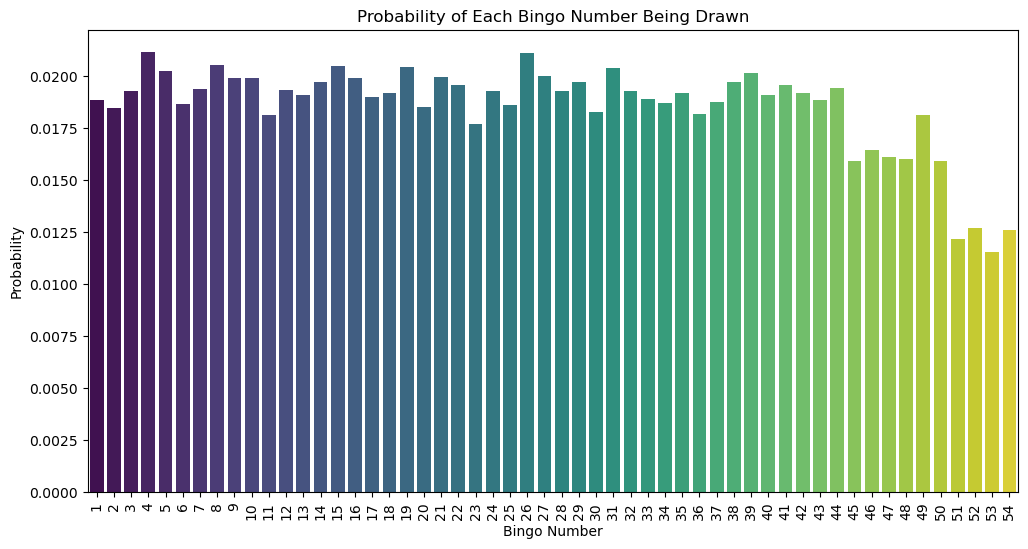

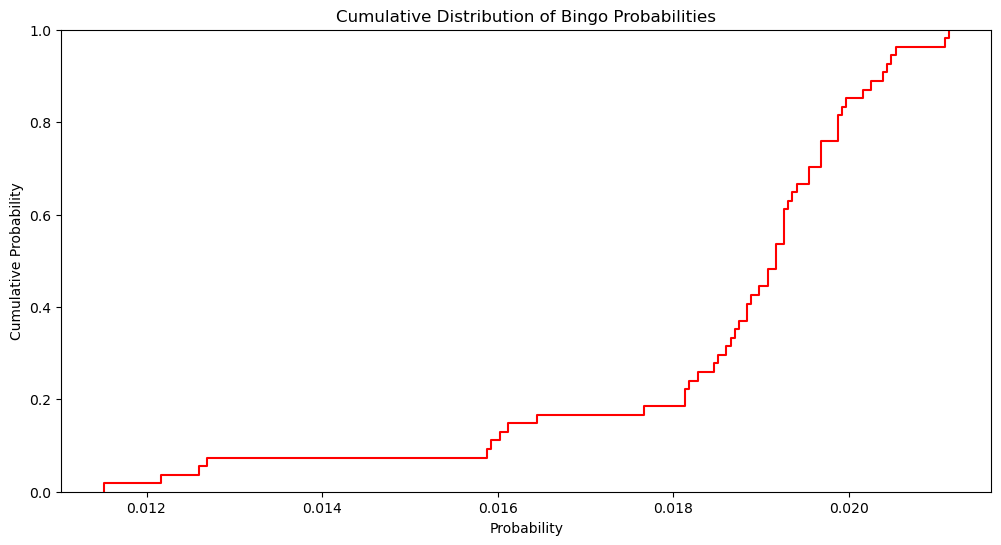

C:\Users\18176\AppData\Local\Temp\ipykernel_2756\1517915128.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_probs = df.groupby("Group")["Probability"].sum().reset_index()


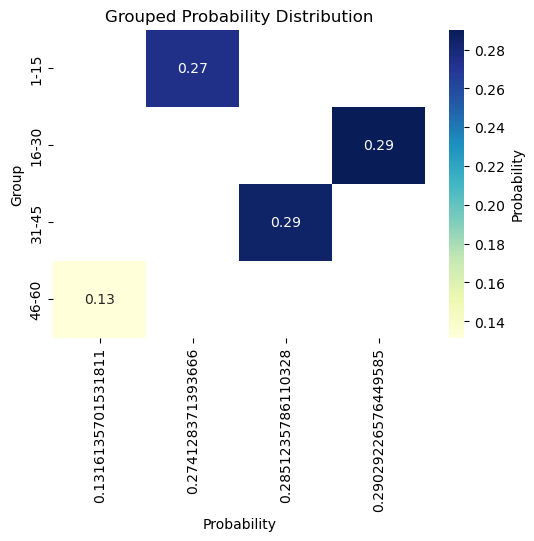

In [38]:
# Convert dictionary to DataFrame
df = pd.DataFrame(list(probability_list.items()), columns=['Number', 'Probability'])

# Sort by probability (descending)
df = df.sort_values(by="Probability", ascending=False)

# --- 1. Bar Plot: Probability of Each Number ---
plt.figure(figsize=(12, 6))
sns.barplot(x='Number', y="Probability", data=df, palette="viridis", legend=False)
plt.xticks(rotation=90)
plt.title("Probability of Each Bingo Number Being Drawn")
plt.xlabel("Bingo Number")
plt.ylabel("Probability")
plt.show()

# --- 2. Cumulative Distribution Plot ---
plt.figure(figsize=(12, 6))
sns.ecdfplot(df["Probability"], color="red")
plt.title("Cumulative Distribution of Bingo Probabilities")
plt.xlabel("Probability")
plt.ylabel("Cumulative Probability")
plt.show()

# --- 3. Optional: Heatmap of Probabilities (Grouped) ---
df["Group"] = pd.cut(df["Number"], bins=[1, 15, 30, 45, 60], labels=["1-15", "16-30", "31-45", "46-60"])
grouped_probs = df.groupby("Group")["Probability"].sum().reset_index()

plt.figure(figsize=(6, 4))
sns.heatmap(grouped_probs.pivot(index="Group", columns="Probability", values="Probability"), annot=True, cmap="YlGnBu", cbar_kws={'label': 'Probability'})
plt.title("Grouped Probability Distribution")
plt.show()